In [1]:
import os
import yaml
import torch
import numpy as np
import pandas as pd
import networkx as nx
from utils import utils
from utils.operation import *
from datetime import datetime
import matplotlib.pyplot as plt
from types import SimpleNamespace
from utils.metrics import select_metric

from Data.data_collect.Merge_collect import Merge_PygDataset
from Data.data_collect.datatype.excel.excel_collect import Excel_PygDataset
from Data.data_collect.datatype.spectrum.spe_collect import Spectrum_PygDataset
from Data.data_collect.datatype.knowledge_map.k_p_collect import Knowledge_graph_PygDataset

from task_data.graph.graph_task_dataset import MolOFADataset
from task_data.graph.graph_construct import ConstructMolCls
from task_data.eval_data_construct import make_data,make_train_data,make_full_dm_list

from Models.LLM.LLM_Encoder import SentenceEncoder
from Models.models import PyGRGCNEdge,BinGraphModel,BinGraphAttModel


from Light.train import lightning_fit
from Light.data_module import DataModule
from Light.metric import flat_binary_func,EvalKit
from Light.template import ExpConfig,GraphPredLightning
from pytorch_lightning.loggers import WandbLogger

def get_logic_label(ordered_txt):
    or_labeled_text = []
    not_and_labeled_text = []
    for i in range(len(ordered_txt)):
        for j in range(len(ordered_txt)):
            c1 = ordered_txt[i]
            c2 = ordered_txt[j]
            txt = "prompt node. Sample category and description: not " + c1[0] + ". " + c1[1][0] + " and not " + c2[
                0] + ". " + c2[1][0]
            not_and_labeled_text.append(txt)
            txt = "prompt node. Sample category and description: either " + c1[0] + ". " + c1[1][0] + " or " + c2[
                0] + ". " + c2[1][0]
            or_labeled_text.append(txt)
    return or_labeled_text + not_and_labeled_text

bin C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\bitsandbytes\libbitsandbytes_cuda116.dll


# 加载配置文件

In [2]:
configs = []
configs.append(
    utils.load_yaml(
        os.path.join(
            #os.path.dirname(__file__), "configs", "default_config.yaml"
            './', "Configs", "default_config.yaml"
        )
    )
)

# 可选的配置更新
# 添加新的config
override_config = utils.load_yaml('./Configs/Override/e2e_all_config_test.yaml')
configs.append(override_config)

# 更新配置
mod_params = utils.combine_dict(*configs)
#mod_params = merge_mod(mod_params, params.opts)
mod_params = utils.merge_mod(mod_params, [])

In [3]:
# 信息存储路径
curtime = datetime.now()
exp_name = str(curtime).replace(" ", "_")
exp_name = exp_name.replace(":", "_")
exp_name = exp_name.replace(".", "_")
exp_name = exp_name.split("_")[0]
exp_dir = os.path.join("./saved_exp", exp_name)
if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)
# 保存并转换配置文件
with open(os.path.join(exp_dir, "command"), "w") as f:  # 保存配置文件
    yaml.dump(mod_params, f)
mod_params["exp_dir"] = exp_dir
params = SimpleNamespace(**mod_params)
utils.set_random_seed(params.seed)
torch.set_float32_matmul_precision("high")
params.log_project = "full_cdm"

params.exp_name += f"_{params.llm_name}_ofa1"

In [4]:
task_config_lookup = utils.load_yaml(
    os.path.join(
        #os.path.dirname(__file__), "configs", "task_config.yaml"
        r'.', "Configs", "task_config.yaml"
        )
)
data_config_lookup = utils.load_yaml(
    os.path.join(
        #os.path.dirname(__file__), "configs", "data_config.yaml"
        r'.',"Configs", "data_config.yaml"
        )
    )
if isinstance(params.task_names, str):
    task_names = [a.strip() for a in params.task_names.split(",")]
else:
    task_names = params.task_names

In [5]:
task_name = params.task_names[0]
dataset_name = params.dataset_names[0]

In [6]:
# utils.set_random_seed(params.seed)   # 固定随机数种为0
# print("PyTorch path: ",torch.__file__)

# 加载化学知识图谱

## 加载元素信息，加载官能团信息

In [7]:
# 加载信息
Knowledge_graph_loader = Knowledge_graph_PygDataset()
FGD = Knowledge_graph_loader.data_loader('.\Datasets\Knowledge graph(chemistry)\knowledge_graph.gexf','graph')

In [8]:
# # 在FGD.data['1']['Data']中，检索边关系包含'has_range'的三元组
# for u,v,m in FGD.data['1']['Data'].edges(data=True):
#     if 'has_range' in m['relation']:
#         print(u,v,m)


## 加载官能团振动吸收信息

In [9]:
# # 进行预处理
# supplement_data_1 = pd.read_excel('.\Datasets\Functional group (chemistry)\Functional_group_data_from_wiki_format.xlsx')
addition_information = Excel_PygDataset()
supplement_data = addition_information.data_loader('.\Datasets\Functional group (chemistry)\Functional_group_data_from_wiki_format.xlsx','text')

### 格式化信息

In [10]:
process_data = addition_information.preprocess()
#process_data = pd_format(supplement_data.data['1']['Data'])

## 混合以上两个图谱，生成完整的化学信息知识图谱

In [11]:
# for i in range(len(process_data)):
#     print(process_data.iloc[i]['Range'])

In [12]:
# 图数据：FGD.data['1']['Data']
G = FGD.data['1']['Data'].copy()
# 给G添加复数节点：节点的名称为'Functional group{}';可能存在的振动节点；光谱范围节点
# 加入relation关系 ，has'range'
# {}为自然数列，从1开始，每个节点包含'raw_text'和'color'两个属性".
Append_node = []
Append_edge = []
for i in range(len(process_data)):
    # 检测该节点是否存在
    Subtype = ('#' + process_data.loc[i,'Subtype']).replace(' ','')
    core = ''

    dictionary_node = []
    dictionary_edge = []

    G.add_node(f'Range{i+1}',raw_text = process_data.iloc[i]['Range'],color = 'purple')
    dictionary_node.append(process_data.iloc[i]['Range'])
    G.add_node(f'S-Strength{i+1}',raw_text = process_data.iloc[i]['S-Strength'],color = 'yellow')
    dictionary_node.append(process_data.iloc[i]['S-Strength'])

    if process_data.iloc[i]['Functional group']!=None:
        core = ('#' + process_data.loc[i,'Functional group']).replace(' ','')
    else:
        core = Subtype
    if core not in G.nodes:
        G.add_node(core,raw_text = 'feature node. Functional group: <{}>.'.format(core),color = 'cyan')
    else:# 给节点core添加属性
        G.nodes[core]['raw_text'] = 'feature node. Functional group: <{}>.'.format(core)
        G.nodes[core]['color'] = 'cyan'
    if not G.has_edge(core,Subtype):
        G.add_edge(core,Subtype,relation='http://www.w3.org/1999/02/22-rdf-syntax-ns#type',id='2736')
            
    # else:# 给节点core添加属性
    #     G.nodes[core]['raw_text'] = 'feature node. Functional group: <{}>.'.format(core)
    #     G.nodes[core]['color'] = 'cyan'
    dictionary_node.append(core)

    # if process_data.iloc[i]['Functional group'] not in G.nodes and process_data.iloc[i]['Functional group']!=None: # 如果有特定的官能团描述，则使用这个描述
    #     core = '#' + process_data.loc[i,'Functional group']
    #     G.add_node(core,raw_text = 'feature node. Functional group: <{}>.'.format(core),color = 'cyan')
    #     core = process_data.iloc[i]['Functional group']  
    # elif process_data.iloc[i]['Functional group'] in G.nodes and process_data.iloc[i]['Functional group']!=None:
    #     core = process_data.iloc[i]['Functional group']
    # else:core = Subtype
    # dictionary_node.append(core)

    if not G.has_edge(core,f'Range{i+1}'):
        G.add_edge(core,f'Range{i+1}',relation='feature edge.The absorption peak of this functional group cover the following range')
        dictionary_edge.append('FP-Ran')
    if not G.has_edge(f'Range{i+1}',f'S-Strength{i+1}'):
        G.add_edge(f'Range{i+1}',f'S-Strength{i+1}',relation='feature edge.The vibrational intensity of this absorption peak is as follows')
        dictionary_edge.append('Ran-Str')

    if process_data.iloc[i]['Absorb']!=None and process_data.iloc[i]['Absorb'] not in G.nodes:
        G.add_node(process_data.iloc[i]['Absorb'],raw_text = process_data.iloc[i]['Absorb'],color = 'yellow')
        dictionary_node.append(process_data.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',process_data.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',process_data.iloc[i]['Absorb'],relation='feature edge.The type of vibration of this absorption peak is as follows')
            dictionary_edge.append('Ran-Ab')
    elif process_data.iloc[i]['Absorb']!=None and process_data.iloc[i]['Absorb'] in G.nodes:
        dictionary_node.append(process_data.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',process_data.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',process_data.iloc[i]['Absorb'],relation='feature edge.The type of vibration of this absorption peak is as follows')
            dictionary_edge.append('Ran-Ab')
    #添加连线
    # 检测连线是否存在
    # if not G.has_edge(core,f'Range{i+1}'):
    #     G.add_edge(core,f'Range{i+1}',relation='has_range')
    #     dictionary_edge.append('FP-Ran')
    # if not G.has_edge(core,f'S-Strength{i+1}'):
    #     G.add_edge(core,f'S-Strength{i+1}',relation='has_strength')
    #     dictionary_edge.append('FP-Str')
    
    Append_node.append(dictionary_node)
    Append_edge.append(dictionary_edge)


In [13]:
# 修改G中Range{}的节点名，用raw_text替换。非必要操作
for i in range(len(process_data)):
    nx.relabel_nodes(G,{f'Range{i+1}':process_data.iloc[i]['Range']},copy=False)

In [14]:
# 文本数据图谱构造
FG_graph = G

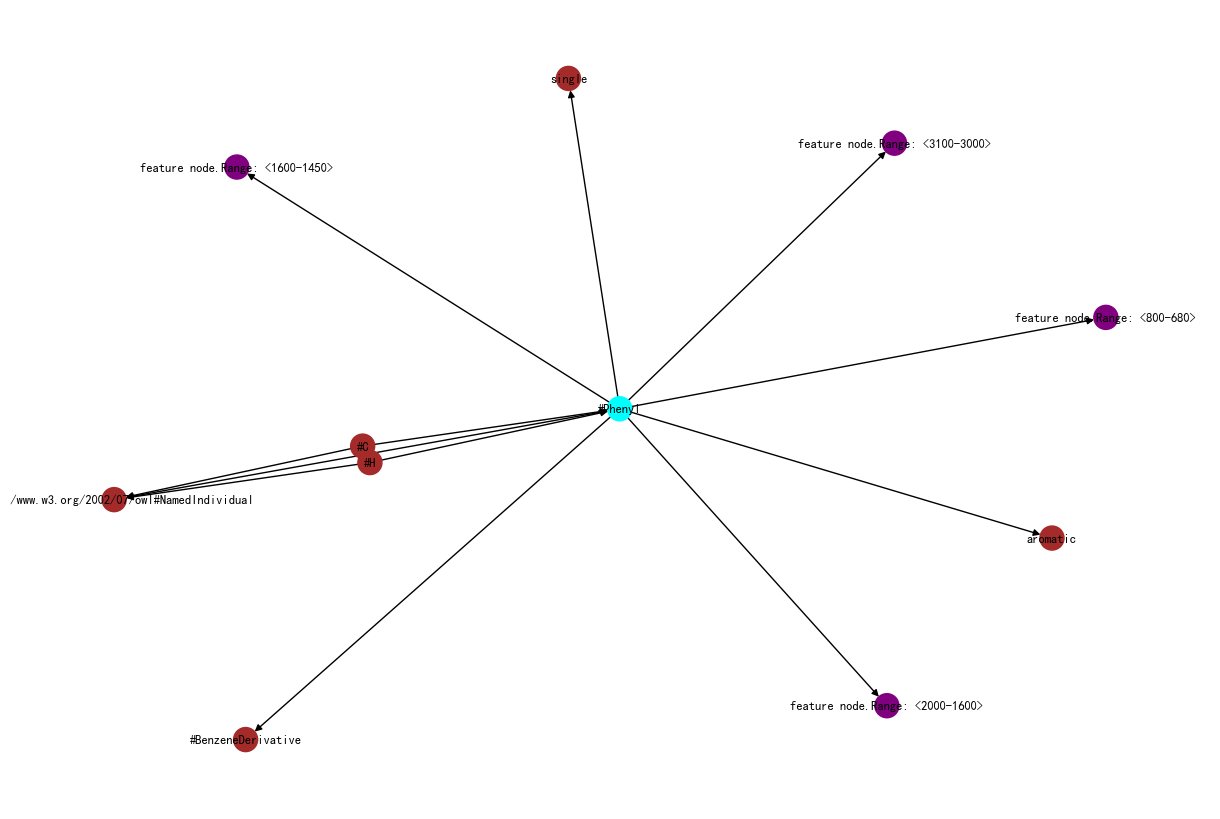

In [15]:
# 展示化学知识子图
# 颜色说明：
# 子类物质名称，如Alkane-烷烃 ——> 棕色
# 官能团名称，如Alkyl-烷基 ——> 青色
# 子结构/振动类型/振动强度，如C-H deformation vibration ——> 黄色
# 吸收区间，如1500-1145 ——> 紫色
# 其余节点，设置为棕色

sub_graph = nx.generators.ego_graph(FG_graph, '#Phenyl', radius=1,undirected=True)
ppp = sub_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [ppp.nodes[n]['color'] for n in ppp.nodes()]
colors = []
for n in ppp.nodes():
    try:colors.append(ppp.nodes[n]['color'])
    except:
        colors.append('brown')
        #print(n)

plt.figure(figsize=(12, 8))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9,node_color=colors)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

# 加载样本光谱信息

## 导入样本信息

In [16]:
# 加载光谱信息
Spectrum_loader = Spectrum_PygDataset()
SD = Spectrum_loader.data_loader('G:\Research\数据集\Pper4-Database\Spectral Database')
# SD里面有名字的相关储存

100%|██████████| 306/306 [00:02<00:00, 131.37it/s]


In [17]:
# # 补充数据掩膜与标签
#label = pd.read_excel(r'G:\Research\数据集\Pper4-Database\spect-分子式+学名.xlsx')
label = pd.read_excel(r'G:\Research\数据集\Pper4-Database\spect-分子式+学名_语义编码.xlsx')
# method_of_mask_1:determine the mask by the proportion of the data
#Mask = ['train'] * 184 + ['valid'] * 61 + ['test'] * 61   # 固定比例为6:2:2
#np.random.shuffle(Mask)
# method_of_mask_2:determine the proportion of every class of the data. split class - > shuffle data -> proportion split - > merge different class
Meta_Data = {}
for i in range(len(label)):
    meta_data = {}
    # 反转标签
    # if label.iloc[i]['标签/双键结构，包括普通双键与芳香族'] == 1:
    #     meta_data['label'] = 0
    # else:meta_data['label'] = 1
    # 正常标签
    meta_data['label'] = label.iloc[i]['标签/双键结构，包括普通双键与芳香族']
    
    Meta_Data[label.iloc[i]['Molecular formula']] = meta_data
Meta_Data = utils.make_mask_proportion(Meta_Data)

# {name:[Mask,Labl]}
# 匹配一下分子名称
# for i in SD.data:
#     print(SD.data[i]['Path'].split('\\')[-2])
#     print(label_dict[SD.data[i]['Path'].split('\\')[-2]])

## 光谱节点化预处理

In [18]:
# 光谱数据预处理
spectrum_dataset = Spectrum_loader.preprocess(SD.data)
#spectrum_dataset['147']['Node']
#Spectrum_loader.pre_data

In [19]:
# 光谱数据图谱构造
# 在这里添加Mask和Label
Spectrum_graph = Spectrum_loader.construct_graph(spectrum_dataset,kwargs=Meta_Data)

In [20]:
# nodes = [f'wavelength{i+1}' for i in range(20)]
# sub_graph = Spectrum_graph['(C5F9)2']['graph'].subgraph(nodes)
# Spectrum_loader.graph_visualisation(sub_graph)

In [21]:
# for node,attr in Spectrum_graph['(C6H4)2']['graph'].nodes(data=True):
#     if 'strength' in node or 'min' in node:
#     #print(node,attr['raw_text'])
#     #if 'wave' in node:
#         print(node,attr['raw_text'])

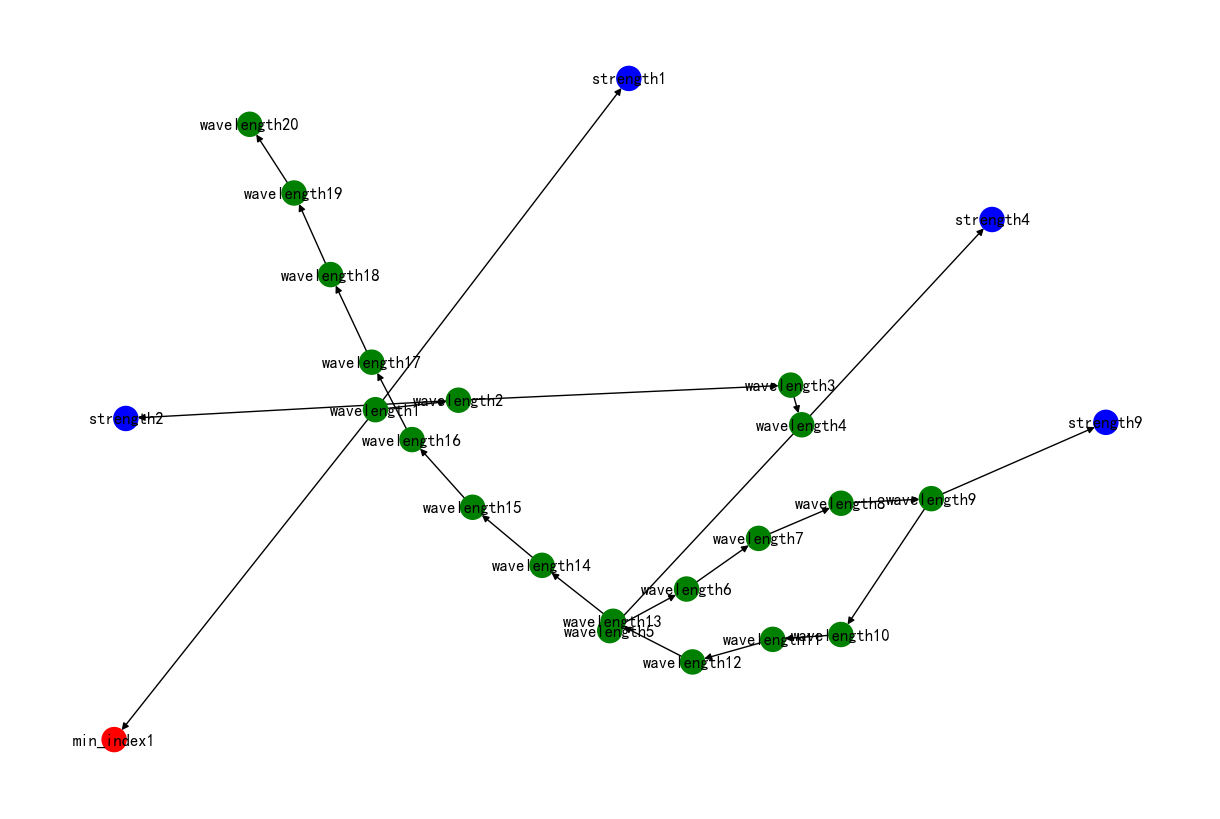

In [22]:
# 图谱可视化
# 颜色说明：
# 波长区间，——> 绿色
# 吸收峰标注及其强度 ——> 蓝色
# 最大吸收位置 ——> 红色

Spectrum_loader.graph_visualisation(Spectrum_graph['(C6H4)2']['graph'])

# 混合化学知识图谱与光谱节点图

In [23]:
## 批量测试
# 批量化处理，测试
test_class = Merge_PygDataset(FG_graph,Spectrum_graph['(C6H4)2'], Name = '(C6H4)2')
connected_dictionary = test_class.preprocess()
all_Table,isexist,score_dict = test_class.Negative_relevant_information(is_print=False)
OP = test_class.construct_graph(connected_dictionary,all_Table,is_print=False)
fin = test_class.subgraph_extraction(hop=2)

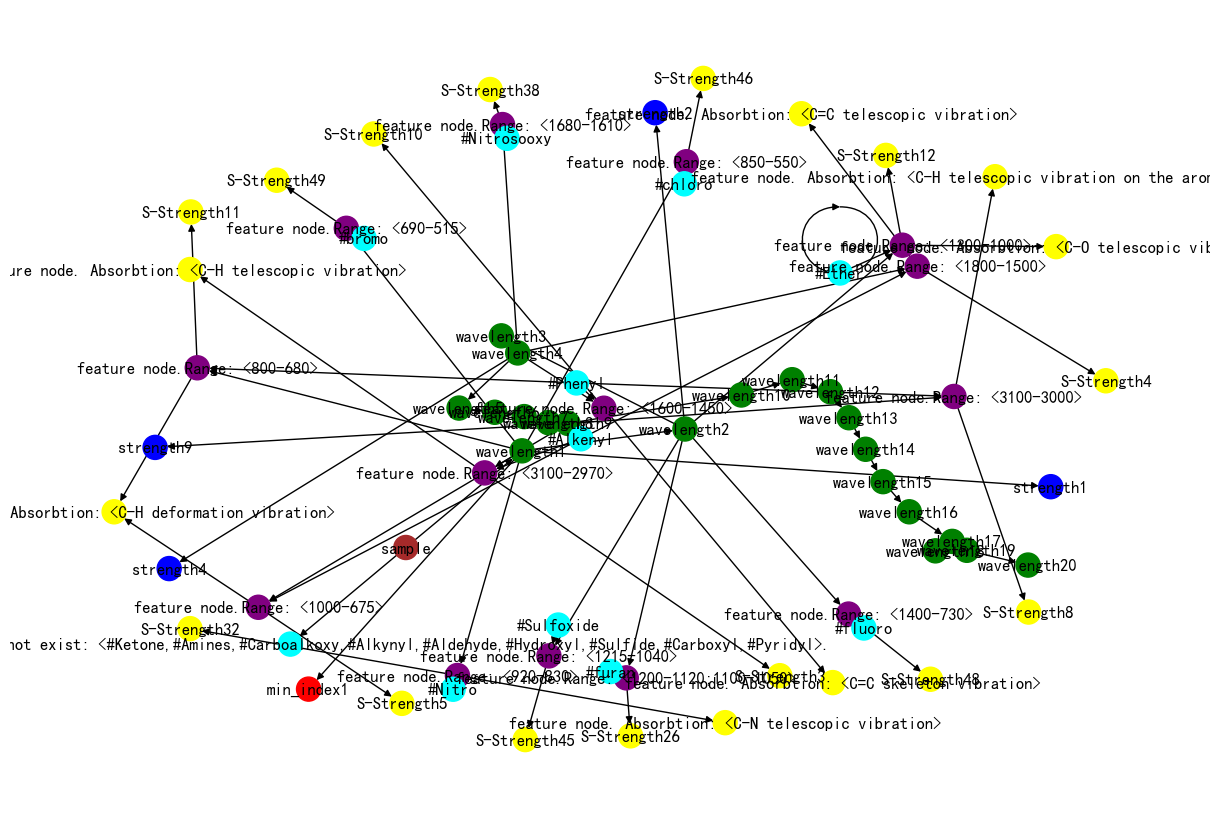

In [24]:
test_class.graph_visualisation(fin)

# 采用大模型将节点信息，边信息转换为文本

## 检测无信息的node，edge

In [25]:
# # 对于huoqu2中的所有节点，如果其属性中不存在'raw_text'，则输出该节点名
# for node,attr in fin.nodes(data=True):
#     if 'raw_text' not in attr.keys():
#         print(node)

# # 对应huoqu2中的所有边线，如果其属性中不存在'relation'，则输出该边线
# for edge1,edge2,attr in fin.edges(data=True):
#     if 'relation' not in attr.keys():
#         print(edge1,edge2)

In [26]:
# 先测试在不同的模式中的转换
# 1.从networkx转换为pyg
pyg_data = test_class.GP.from_networkx_2_pyg(fin)
pyg_data.keys()

['edge_index', 'edge_attributes', 'node_attributes', 'node_name', 'x']

In [27]:
# 2.从pyg转换为networkx
nx_data = test_class.GP.from_pyg_2_networkx(pyg_data)
networkx_graph = nx_data

In [28]:
utils.compare_edge(fin,networkx_graph)
utils.compare_node(fin,networkx_graph)

## 保存原始数据

In [29]:
# import pickle
# # # # # # 保存Spectrum_graph文件
# with open('./Datasets/Base_data/Spectrum_graph.pkl', 'wb') as f:
#     pickle.dump(Spectrum_graph, f)
# # # # # # # # # # 保存FG_graph文件
# with open('./Datasets/Base_data/FG_graph.pkl', 'wb') as f:
#     pickle.dump(FG_graph, f)

In [30]:
# # 读取Spectrum_graph文件
# with open('./Datasets/Base_data/Spectrum_graph.pkl', 'rb') as f:
#     Load_spec = pickle.load(f)

## 构建train，valid，test部分

### get_ofa_data

In [31]:
# 0. Check GPU setting.
device, gpu_ids = utils.get_available_devices()
gpu_size = len(gpu_ids)
gpu_size

1

In [32]:
# 初始化编码器
# 可选配置 - LLM_DIM_DICT = {"ST": 768, "BERT": 768, "e5": 1024, "llama2_7b": 4096, "llama2_13b": 5120}
#utils.set_random_seed(0)

encoder = SentenceEncoder(
                params.llm_name,
                batch_size = params.llm_b_size,
                )


In [33]:
# 测试集群数据编辑效果
# from task_data.graph.graph_task_dataset import get_local_text,gen_graph
# a,b,c = gen_graph(get_local_text((FG_graph,Spectrum_graph)))

# # check label
# for i in b[2]:
#     print(i)  # 标签语义
# for num,i in enumerate(a):
#     if num >= 10: break
#     print(i.name,i.y_label)  # 样本标签

In [34]:
# # # check label
# for i in b[2]:
#     print(i)  # 标签语义
# for num,i in enumerate(a):
#     if num >= 10: break
#     print(i.Name,i.y_label)  # 样本标签

In [35]:
# # 1.直接从这里获取的边信息
# sample_graph = g.GP.from_networkx_2_pyg(g.GP.finnal_graph)
# sample_graph.edge_index

# # 2.转换1次
# nx_z = pyg.utils.to_networkx(sample_graph,to_undirected=False,to_multi=True)

# #torch.tensor(list(nx_z.edges())).T
# # 比较sample_graph.edge_index和torch.tensor(list(nx_z.edges())).T是否相同
# torch.tensor(list(nx_z.edges())).T == sample_graph.edge_index

In [36]:
# 这里实质上完成了函数： get_ofa_data
dataset_output = MolOFADataset(name = task_name,  # 单类任务
              load_texts = params.load_texts,
              encoder=encoder,
              force_reload = True
               )
# dataset_output.data       # 堆叠后的数据,可与get()函数合用,用索引获取数据样本
# dataset_output.slices     # data的切片索引
# dataset_output.side_data  # 数据集划分与任务映射
# dataset_output.get(0)
# dataset_output.get_idx_split() #获取数据集的划分
# dataset_output.get_task_map() #获取任务映射
# dataset_output.get_edge_list() #获取任务类型

In [37]:
dataset_output.get_information_pyg()
# dataset_output[0].y_label
# dataset_output.class_node_text_feat[0]

Name  : 样本名称
edge_ID  : 边标签
edge_attributes  : 边属性
edge_index  : 邻接矩阵
edge_text_feat  : 边文本信息矩阵
node_ID  : 节点标签
node_attributes  : 节点属性
node_name  : 节点名称
node_text_feat  : 节点文本信息矩阵
x  : 节点记号
y  : 编码分类标签
y_label  : 原始分类标签


In [38]:
# dataset_output.get_prompt_text_feat('e2e_graph').keys() # Prompt的相关部分

In [39]:
# 读取保存的数据
# ["geometric_data_processed.pt", "texts.pkl", "data.pt"]
# side_data  -- self.processed_path[2]
# texts  -- self.processed_paths[1]
# data（这里的形式是堆叠以后的数据，还有切片索引） --  self.processed_path[0]

# k_1,k_2 =torch.load(r"G:\Research\Paper4-Code\2024_5_13\cache_data\Base_classification\test\processed\geometric_data_processed.pt") # 保存了data的路径

In [40]:
# 在运转任务类里面的集成格式
# self.dataset = {}  # keyed by base dataset names e.g. cora, pubmed and not cora-link
# self.dataset_split = {}  # keyed by dataset names and task level e.g. cora_e2e_link
# self.preprocess_storage = {}  # keyed by dataset names and task level e.g. cora_e2e_link
# self.datamanager = {}
# self.edges = {}
# self.datasets = {"train": [], "valid": [],
#                     "test": []}  # train a list of Dataset, valid/test a list of DataWithMeta
# self.stage_names = {"train": [], "valid": [], "test": []}

In [41]:
# # 这里两个数据集的名字，第一个是task_config里面的，第二个是data_config里面的
# task_config = {'task_level': 'e2e_graph', 
#                'eval_pool_mode': 'mean', 
#                'eval_set_constructs':[{'stage': 'train', 'split_name': 'train','dataset': 'small_molecule'}, {'stage': 'valid', 'split_name': 'valid','dataset': 'small_molecule'}, {'stage': 'test', 'split_name': 'test','dataset': 'small_molecule'}, {'stage': 'test', 'split_name': 'train','dataset': 'small_molecule'},{'stage': 'test', 'split_name': 'valid','dataset': 'small_molecule'}], 
#                'dataset':'small_molecule'}

# Stage_Config = task_config['eval_set_constructs']
# stage_config = Stage_Config[0]

# dataset_config = {
# 'task': 'classification',
# 'task_level': 'e2e_graph',               # 命名
# 'dataset_splitter': 'Graph_splitter',   # 分割器
# 'preprocess': None, 
# 'construct': 'ConstructMolCls',    # 构造器
# 'args': {'walk_length': None}, 
# 'eval_mode': 'max', 
# 'dataset_name': 'small_molecule',            # 命名
# 'process_label_func': 'process_reverse_binary_label', 
# 'eval_metric': 'auc', 
# 'eval_func': 'binary_auc_func', 
# 'num_classes': 3
# }

In [42]:
# task_config = task_config_lookup[params.dataset_names[0]]
# dataset_config = data_config_lookup[params.dataset_names[0]]
task_config = utils.get_task_config(task_name,dataset_name,task_config_lookup)
dataset_config = utils.get_dataset_config(task_name,dataset_name,data_config_lookup)

Stage_Config = task_config['eval_set_constructs']
stage_config = Stage_Config[0]

# 数据集字典化
test_dataset = {}   # 储存总数据集
test_dataset_split = {}    # 储存划分子数据集的掩膜
test_preprocess_storage = {}   # 储存预处理结果
test_datasets = {"train": [], "valid": [],"test": []}   # 储存子数据集
test_stage_names = {"train": [], "valid": [], "test": []}

In [43]:
result = []
result_valid = []
for i in Stage_Config:
    if "dataset_names" not in i:  # 如果没有更换不同的数据集，此时默认的数据集为 config["dataset"]，即外层标的那个
            i["dataset_names"] = task_config["dataset_name"]
    test_dataset[dataset_config['dataset_name']] = dataset_output   # 加载总数据集
    test_dataset_split, split_key = get_data_split(test_dataset,test_dataset_split,dataset_config)   # 根据stage划分不同的子数据集
    stage_name = get_stage_name(i, dataset_config)    # 获取对应的子数据集名称
    #if i["stage"] != "train" and stage_name in test_stage_names[i["stage"]]: #包括验证和测试的数据集只构建一次
    if stage_name in test_stage_names[i["stage"]]: #子数据集只构建一次
        result.append(test_stage_names[i["stage"]].index(stage_name)) # 返回这个eval数据集的索引
        if i["stage"] == "valid":
            result_valid.append([test_stage_names[i["stage"]].index(stage_name)])
        continue
    test_preprocess_storage, split_key = get_global_data(test_dataset,test_dataset_split,test_preprocess_storage,dataset_config)
    prompt_feats = dataset_output.get_prompt_text_feat(dataset_config["task_level"]) # Prompt的相关部分
    data = ConstructMolCls(dataset = test_dataset[dataset_config['dataset_name']], 
                       split = test_dataset_split[split_key], 
                       split_name = i["split_name"],
                       prompt_feats = prompt_feats, 
                       to_bin_cls_func = dataset_config["process_label_func"] if dataset_config.get("process_label_func") else None,
                       task_level = dataset_config["task_level"], 
                       global_data = test_preprocess_storage[split_key],
                       **dataset_config["args"], 
                       )
    if i["stage"] == "train":
        test_datasets[i["stage"]].append(data)
    else:
        eval_data = make_data(i["dataset_names"], 
                            data, 
                            i["split_name"],
                            dataset_config["eval_metric"], 
                            dataset_config["eval_func"],
                            dataset_config["num_classes"], 
                            #batch_size=20,
                            batch_size=params.batch_size,
                            #sample_size=-1, 
                            sample_size=params.eval_sample_size,
                            eval_mode=dataset_config["eval_mode"])
        test_datasets[i["stage"]].append(eval_data)
    test_stage_names[i["stage"]].append(stage_name)
    result.append(test_stage_names[i["stage"]].index(stage_name))
    if i["stage"] == "valid":
        result_valid.append([test_stage_names[i["stage"]].index(stage_name)])  # 获取索引

In [44]:
# for index,number_index in enumerate(test_dataset_split['small_molecule-e2e_graph-Base_classification']['train']):
#     origin_name = dataset_output[number_index].Name   # 原始名字
#     set_name = test_datasets['train'][0][index].Name
#     label = test_datasets['train'][0][index].y
#     print(set_name,label)

In [45]:
# # 获取原数据集与切分后的数据集分布，以'train'为例
# for index,number_index in enumerate(test_dataset_split['small_molecule-e2e_graph-Base_classification']['train']):
#     origin_name = dataset_output[number_index].Name   # 原始名字
#     set_name = test_datasets['train'][0][index].Name
#     if origin_name == set_name[0]:
#         pass
#     else:
#         print(origin_name,set_name[0])


In [46]:
val_task_index_lst = result_valid
val_pool_mode = task_config['eval_pool_mode']
print(result,'\n',result_valid,'\n',val_pool_mode)

[0, 0, 0, 1, 2] 
 [[0]] 
 mean


In [47]:
# for i in test_dataset_split['small_molecule-e2e_graph-Base_classification']['train']:
#     print(dataset_output[i].Name, dataset_output[i].y)

In [48]:
if encoder is not None:
    encoder.flush_model()

In [49]:
def transform_2_binary(predict):
    # 将predict每隔2个元素分为1组，在这一组中，更大的元素转换为1，更小的元素转换为0
    result = []
    for i in range(0,len(predict),2):
        if predict[i] > predict[i+1]:
            result.append(1)
            result.append(0)
        else:
            result.append(0)
            result.append(1)
    return result

def compare_list(predict,ground_truth):
    score = 0
    for i in range(len(predict)):
        if predict[i] == ground_truth[i]:
            score += 1
    return score/len(predict)

In [50]:
# predict = [
# -0.4149,  0.2675, -0.0475,  0.1032, -0.1218, -0.0140, -0.3574, -0.3145,
# -0.1469, -0.6508, -0.0994,  0.9657, -0.4005, -0.6598,  0.2460, -0.3518,
# -0.0267, -0.1580,  0.0195, -0.1734, -0.8670, -0.3456,  0.0409, -0.2653,
#  -0.2551, -0.1756, -0.1159, -0.1787, -0.4130, -0.3629,  0.1959, -0.2439,
#  -0.1461, -0.1065, -0.3476,  0.0106,  0.4526, -0.5268, -0.2620, -0.0775
# ]
# ground_truth = [1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
#   0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
#   0, 1, 1, 0]
# predict_result = (transform_2_binary(predict))
# print(predict_result)
# compare_list(predict_result,ground_truth)


In [51]:
# predict = [-0.795,-1.1491,-0.7947,-1.1484,-0.7961,-1.1499,-0.7980,-1.1515,-0.7969,-1.1508,-0.7992,-1.1513,-0.7962,-1.1498,-0.7984,-1.1512,-0.7994,-1.1518,-0.7994,-1.1517,-0.7947,-1.1488,-0.7940,-1.1482,-0.7989,
# -1.1517,-0.7982,-1.1520,-0.7981,-1.1514,-0.7978,-1.1518,-0.7978,-1.1515,-0.7960,-1.1488,-0.7960,-1.1493,-0.7956,-1.1488]

# ground_truth = [1,0,1,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0,0,1,1,0,1,0,0,1,0,1,0,1,0,1,0,1,1,0,1,0,1,0]
# predict_result = (transform_2_binary(predict))
# print(predict_result)
# compare_list(predict_result,ground_truth)


In [52]:
# 调用损失函数BCEWithLogitsLoss()给上面两个结果进行打分
# from torch import nn
# from torch.autograd import Variable
# bce_criterion = nn.BCEWithLogitsLoss(weight = None, reduce = False)

In [53]:
#[0.4126, 0.4125, 0.4125, 0.4125, 0.4124, 0.4129, 0.4125, 0.4127, 0.4128,0.4128, 0.4124, 0.4124, 0.4127, 0.4124, 0.4126, 0.4124, 0.4125, 0.4127,0.4126, 0.4126]
#[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0]
#Binary_AUC()

# 训练

In [54]:
# 1.以上只处理了单个，需要将全部样本打包为训练集，测试集
# 2.构造训练模型

## 加载模型

In [55]:
# 补充一个config提供参数

out_dim = params.emb_dim + (params.rwpe if params.rwpe is not None else 0)

gnn = PyGRGCNEdge(
    params.num_layers,
    5,
    out_dim,
    out_dim,
    drop_ratio=params.dropout,
    JK=params.JK,
)

bin_model = BinGraphAttModel if params.JK == "none" else BinGraphModel
model = bin_model(
                model=gnn, 
                llm_name=params.llm_name, 
                outdim=out_dim, 
                task_dim=len(params.task_names),
                add_rwpe=params.rwpe, 
                dropout=params.dropout
                )

## Construct datasets and lightning datamodule.

In [56]:
if hasattr(params, "d_multiple"):
    if isinstance(params.d_multiple, str):
        data_multiple = [float(a) for a in params.d_multiple.split(",")]
    else:
        data_multiple = params.d_multiple
else:
    data_multiple = [1]

if hasattr(params, "d_min_ratio"):
    if isinstance(params.d_min_ratio, str):
        min_ratio = [float(a) for a in params.d_min_ratio.split(",")]
    else:
        min_ratio = params.d_min_ratio
else:
    min_ratio = [1]

In [57]:
train_data = make_train_data(
                test_datasets,
                data_multiple, 
                min_ratio, 
                data_val_index=val_task_index_lst
                )
text_dataset = make_full_dm_list(
                test_datasets, 
                data_multiple, 
                min_ratio, 
                train_data,
                batch_size=params.batch_size,
                sample_size=params.train_sample_size,
                )
params.datamodule = DataModule(
                text_dataset, 
                gpu_size=gpu_size, 
                num_workers=params.num_workers  # 默认为0
)

In [58]:
print(text_dataset['train'].data.datas[0].get_collate_fn)   # 训练集的数据整理方法
print(text_dataset['val'][0].data.get_collate_fn)  # 验证集的数据整理方法
print(text_dataset['test'][0].data.get_collate_fn)  # 测试集的数据整理方法

<bound method GraphprocessDataset.get_collate_fn of <task_data.graph.graph_construct.GraphListHierDataset object at 0x0000029A8BC3E800>>
<bound method GraphprocessDataset.get_collate_fn of <task_data.graph.graph_construct.GraphListHierDataset object at 0x0000029A8BA444C0>>
<bound method GraphprocessDataset.get_collate_fn of <task_data.graph.graph_construct.GraphListHierDataset object at 0x0000029A8BA44610>>


In [59]:
# from task_data.base_construct import DatasetWithCollate
# from torch_geometric.data import Dataset as PygDataset
# isinstance(test_datasets['valid'][0].data, DatasetWithCollate)
# isinstance(test_datasets['valid'][0].data.g, PygDataset)

# print(text_dataset['train'].data)
# print(text_dataset['train'].sample_size)
# print(text_dataset['train'].batch_size)

# print(text_dataset['val'][0].data)
# print(text_dataset['val'][0].sample_size)
# print(text_dataset['val'][0].batch_size)

#print(isinstance(text_dataset['train'].data, DatasetWithCollate))
#print(isinstance(text_dataset['train'].data.datas[0].g, PygDataset))

In [60]:
# text_dataset['train'].data.datas[0].llm_max_length

## Initiate evaluation kit

In [61]:
#test_state

In [62]:
#text_dataset['val'][0].data[0].num_classes

In [63]:
eval_data = text_dataset["val"] + text_dataset["test"]
val_state = [dt.state_name for dt in text_dataset["val"]]
test_state = [dt.state_name for dt in text_dataset["test"]]
eval_state = val_state + test_state
eval_metric = [dt.metric for dt in eval_data]                   # 'auc'
eval_funcs = [dt.meta_data["eval_func"] for dt in eval_data]
loss = torch.nn.BCEWithLogitsLoss() # 用于训练的损失函数
evlter = []

In [64]:
for dt in eval_data:
    if dt.metric == "acc":
        evlter.append(select_metric(name = dt.metric, num_classes = dt.classes).metric)
    elif dt.metric == "auc":
        evlter.append(select_metric(name = dt.metric, task = 'binary').metric)
    elif dt.metric == "apr" or dt.metric == "aucmulti":
        evlter.append(select_metric(name = dt.metric, num_labels = dt.classes).metric)

In [65]:
metrics = EvalKit(
    eval_metric,
    evlter,
    loss,
    eval_funcs,
    flat_binary_func,
    eval_mode=dataset_config['eval_mode'], # 'max'
    exp_prefix="",    # 记录前缀
    eval_state=eval_state,  # 文本记号
    val_monitor_state=val_state[0],
    test_monitor_state=test_state[0],    # 开始记录？
)

### Initiate optimizer, scheduler and lightning model module

In [66]:
optimizer = torch.optim.Adam(
    model.parameters(), lr=params.lr, weight_decay=params.l2
)
lr_scheduler = {
    "scheduler": torch.optim.lr_scheduler.StepLR(optimizer, 15, 0.5),
    "interval": "epoch",
    "frequency": 1,
}

In [67]:
exp_config = ExpConfig(
    "",
    optimizer,
    dataset_callback=train_data.update,
    lr_scheduler=lr_scheduler,
)
exp_config.val_state_name = val_state
exp_config.test_state_name = test_state

In [68]:
metrics.eval_states

['valid_small_molecule',
 'test_small_molecule',
 'train_small_molecule',
 'valid_small_molecule']

In [69]:
pred_model = GraphPredLightning(exp_config, model, metrics)

In [70]:
#pred_model._modules.keys()

In [71]:
print(pred_model.exp_config.train_state_name)
print(pred_model.eval_kit.has_eval_state)
print(pred_model.model)

['train_eval']
<bound method EvalKit.has_eval_state of EvalKit(
  (loss): BCEWithLogitsLoss()
  (evlters): ModuleDict(
    (valid_small_molecule): BinaryAUROC()
    (test_small_molecule): BinaryAUROC()
    (train_small_molecule): BinaryAUROC()
  )
)>
BinGraphAttModel(
  (model): PyGRGCNEdge(
    (conv): ModuleList(
      (0): RGCNEdgeConv(768, 768)
      (1): RGCNEdgeConv(768, 768)
      (2): RGCNEdgeConv(768, 768)
      (3): RGCNEdgeConv(768, 768)
      (4): RGCNEdgeConv(768, 768)
      (5): RGCNEdgeConv(768, 768)
      (6): RGCNEdgeConv(768, 768)
    )
    (batch_norm): ModuleList(
      (0): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): BatchNorm1d(768, eps=1e-05, mo

In [72]:
# 对collate_fn的测试：先加载datasetloader
train_datasets_in_test = params.datamodule.train_dataloader()

In [73]:
# valid_datasets_in_test = params.datamodule.test_dataloader()

In [74]:
# valid_datasets_in_test

In [75]:
# len(valid_datasets_in_test[2])

In [76]:
# text_dataset['val'][0].data.__len__()

In [77]:
# sample_size = -1 means full dataste
# valid_datasets_in_test[0].batch_size

In [78]:
# text_dataset['train'].data[0].bin_labels

In [79]:
len(train_datasets_in_test)

10

In [80]:
# for batch in train_datasets_in_test:
#     print(batch)
#     break

In [81]:
# batch.y.shape

In [82]:
type(train_datasets_in_test)

torch.utils.data.dataloader.DataLoader

In [83]:
#(text_dataset['train'].data.datas[0][0].x)[np.argsort(text_dataset['train'].data.datas[0][0].x)]

In [84]:
# text_dataset['train'].data.datas[0].get_collate_fn()

### Start training and logging

In [85]:
wandb_logger = WandbLogger(
    project=params.log_project,
     name=params.exp_name,
    save_dir=params.exp_dir,
    offline=params.offline_log,
)

In [86]:
strategy = "deepspeed_stage_2" if gpu_size > 1 else "auto"
val_res, test_res = lightning_fit(
    wandb_logger,
    pred_model,
    params.datamodule,
    metrics,
    params.num_epochs,
    strategy=strategy,
    save_model=False,
    load_best=params.load_best,
    reload_freq=1,
    test_rep=params.test_rep,
    val_interval=params.val_interval
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id wdsvl94f.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type             | Params
----------------------------------------------
0 | model    | BinGraphAttModel | 28.9 M
1 | eval_kit | EvalKit          | 0     
----------------------------------------------
28.9 M    Trainable params
0         Non-trainable params
28.9 M    Total params
115.704   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\lightning\pytorch\loops\fit_loop.py:298: The number of training batches (10) is smaller than the logging interval Trainer(log_every_n_steps=20). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

valid_small_molecule\loss:0.305284±0.000000
valid_small_molecule\auc:0.958843±0.000000


C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:441: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


test_small_molecule\loss/dataloader_idx_0:0.368243±0.000000
test_small_molecule\auc:0.956989±0.000000
train_small_molecule\auc:0.998791±0.000000
valid_small_molecule\auc:0.958843±0.000000
